# Phase 2 — Data preprocessing (CUAD → DL-ready CSV)

## Goal

**How is CUAD transformed into a deep-learning–ready dataset?**

### Pipeline (matches audited Phase 1 rules)

1. **Long table** — unpivot `master_clauses.csv` to one row per (contract × category) with `clause_text`, `answer`, and `has_real_clause`.
2. **Filtering** — keep rows with **real** spans (not the placeholder `[]`).
3. **Anomaly removal** — drop the rare **Yes** answers with **no** span (same two rows as Part 03).
4. **Text normalization** — strip, collapse whitespace, character cap.
5. **Optional min token filter** — CLI `--min-words-gt` in the builder.
6. **Length features** — `length`, `log_length` for fusion models.
7. **Document-level split** — no filename appears in more than one of train/val/test.
8. **Label encoding** — `label2id.json` + integer `label_id` column.

Code lives in **`src/phase2/data/dl_dataset_builder.py`** (one-time build). Training reads **`dataset_loader`** only.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2.data.dl_dataset_builder import build_dl_dataset, save_build_result
from src.phase2.data.dataset_loader import load_processed_splits, load_dataset_manifest

MASTER = PROJECT_ROOT / "data" / "CUAD_v1" / "master_clauses.csv"
OUT = PROJECT_ROOT / "data" / "processed"

result = build_dl_dataset(MASTER, task="multiclass_real_spans")
save_build_result(result, OUT)
print("Saved under", OUT)


Wrote: /Users/divyanshisachan/Desktop/agastya/data/processed/train.csv /Users/divyanshisachan/Desktop/agastya/data/processed/val.csv /Users/divyanshisachan/Desktop/agastya/data/processed/test.csv /Users/divyanshisachan/Desktop/agastya/data/processed/label2id.json /Users/divyanshisachan/Desktop/agastya/data/processed/dataset_manifest.json
Saved under /Users/divyanshisachan/Desktop/agastya/data/processed


In [2]:
train_df, val_df, test_df, label2id = load_processed_splits(
    OUT / "train.csv",
    OUT / "val.csv",
    OUT / "test.csv",
    label2id_path=OUT / "label2id.json",
)
manifest = load_dataset_manifest(OUT / "dataset_manifest.json")
print("Train rows:", len(train_df), "| Labels:", len(label2id))
print("avg_length (train, tokens):", manifest.get("avg_length"))


Train rows: 5406 | Labels: 41
avg_length (train, tokens): 80.11080281169072


### Class distribution (train)

Imbalance is expected on CUAD; use macro-F1 / class weights in training.


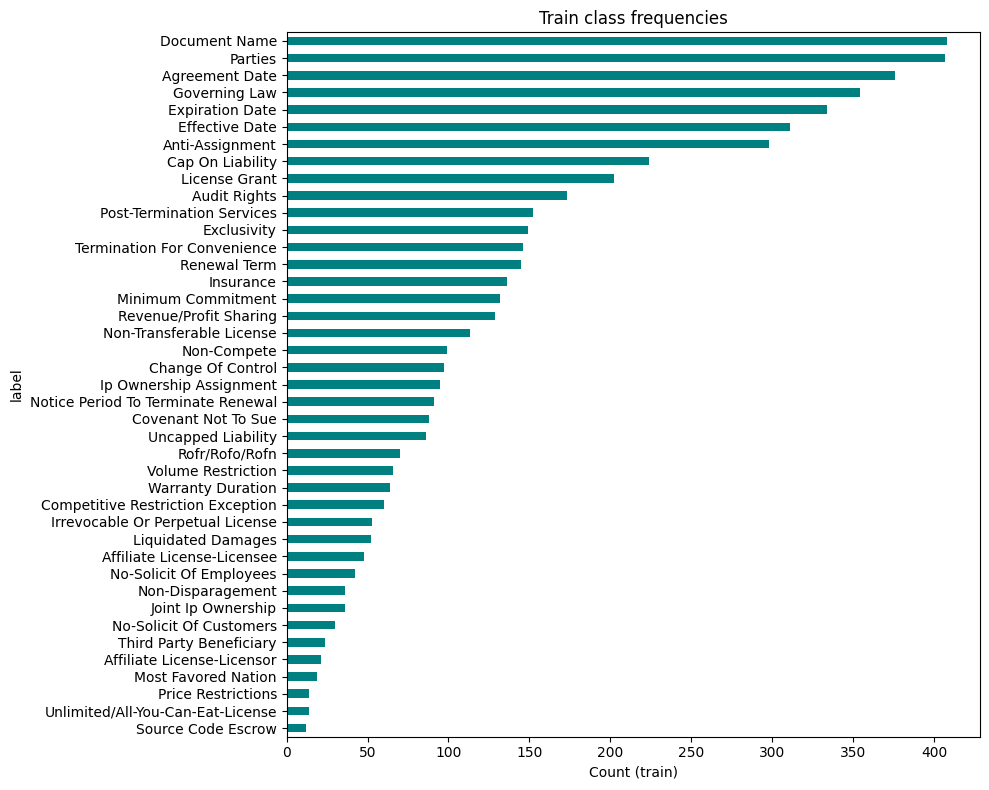

In [3]:
vc = train_df["label"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
vc.plot(kind="barh", ax=ax, color="teal")
ax.set_xlabel("Count (train)")
ax.set_title("Train class frequencies")
plt.tight_layout()
plt.show()


### Length distribution (train tokens)

The **`length`** column is whitespace token count (same construction as `log_length` in the CSV).


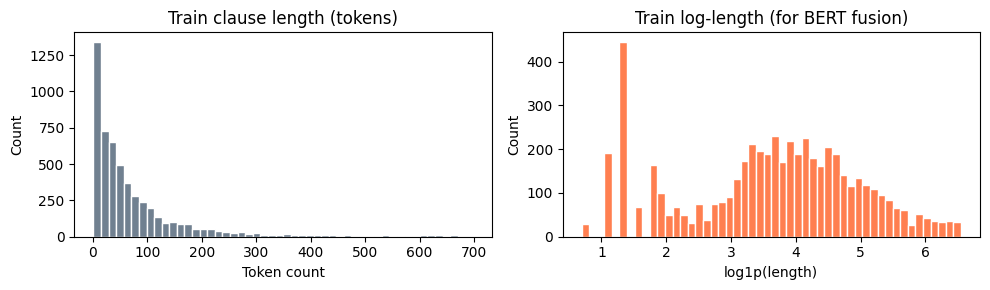

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(train_df["length"], bins=50, color="slategray", edgecolor="white")
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("Count")
axes[0].set_title("Train clause length (tokens)")
axes[1].hist(train_df["log_length"], bins=50, color="coral", edgecolor="white")
axes[1].set_xlabel("log1p(length)")
axes[1].set_ylabel("Count")
axes[1].set_title("Train log-length (for BERT fusion)")
plt.tight_layout()
plt.show()
